In [1]:
# ── Import all required libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')   # suppress minor warnings for cleaner output

# ── Global plot style ──────────────────────────────────────────────────────────
# 'fivethirtyeight' gives clean, readable charts (inspired by FiveThirtyEight data journalism)
plt.style.use('fivethirtyeight')

# Set figure defaults: larger size, high resolution
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

print("✅ Libraries imported successfully!")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Libraries imported successfully!
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


In [2]:
# ── Load CSV files ─────────────────────────────────────────────────────────────
# If you uploaded the files directly to Colab, they land in /content/
matches    = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

print(f"✅ matches.csv    → {matches.shape[0]:,} rows × {matches.shape[1]} columns")
print(f"✅ deliveries.csv → {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns")

# Quick peek at matches
print("\n── First 3 rows of matches.csv ──")
matches.head(3)

✅ matches.csv    → 1,095 rows × 20 columns
✅ deliveries.csv → 233,222 rows × 17 columns

── First 3 rows of matches.csv ──


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [3]:
# Quick peek at deliveries
print("── First 3 rows of deliveries.csv ──")
deliveries.head(3)

── First 3 rows of deliveries.csv ──


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1.0,Kolkata Knight Riders,Royal Challengers Bangalore,0.0,1.0,SC Ganguly,P Kumar,BB McCullum,0.0,1.0,1.0,legbyes,0.0,NaN,NaN,NaN
1,335982,1.0,Kolkata Knight Riders,Royal Challengers Bangalore,0.0,2.0,BB McCullum,P Kumar,SC Ganguly,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN
2,335982,1.0,Kolkata Knight Riders,Royal Challengers Bangalore,0.0,3.0,BB McCullum,P Kumar,SC Ganguly,0.0,1.0,1.0,wides,0.0,NaN,NaN,NaN


In [4]:
# ── Team name standardisation ──────────────────────────────────────────────────
# Some franchises rebranded over the years; we map old names → current names
team_rename = {
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
    'Rising Pune Supergiants'     : 'Rising Pune Supergiant',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Pune Warriors'               : 'Pune Warriors India',
}

# Apply rename to every team-related column in matches
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_rename)

# Apply rename in deliveries (batting/bowling team columns)
for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_rename)

# ── Drop matches with no result (rain, abandoned, etc.) ────────────────────────
# 'winner' column is NaN for no-result matches
matches_clean = matches.dropna(subset=['winner']).copy()
dropped = len(matches) - len(matches_clean)
print(f"Dropped {dropped} no-result matches.")
print(f"Working with {len(matches_clean):,} valid matches across {matches_clean['season'].nunique()} seasons.")

# ── Missing value summary ──────────────────────────────────────────────────────
print("\n── Missing values in matches (top columns) ──")
missing = matches_clean.isnull().sum()
print(missing[missing > 0])

Dropped 5 no-result matches.
Working with 1,090 valid matches across 17 seasons.

── Missing values in matches (top columns) ──
city               51
result_margin      14
method           1069
dtype: int64


## 📊 Quick Data Overview

In [6]:
# ── Dataset summary statistics ─────────────────────────────────────────────────
print("=" * 50)
print("IPL DATASET OVERVIEW")
print("=" * 50)
print(f"  Seasons covered  : {sorted(matches_clean['season'].unique())}")
print(f"  Total matches    : {len(matches_clean):,}")
print(f"  Total deliveries : {len(deliveries):,}")
print(f"  Teams            : {matches_clean['team1'].nunique()}")
print(f"  Venues           : {matches_clean['venue'].nunique()}")
print(f"  Cities           : {matches_clean['city'].nunique()}")

# Unique players who batted
print(f"  Batsmen in data  : {deliveries['batter'].nunique():,}")
print(f"  Bowlers in data  : {deliveries['bowler'].nunique():,}")

IPL DATASET OVERVIEW
  Seasons covered  : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
  Total matches    : 1,090
  Total deliveries : 233,222
  Teams            : 15
  Venues           : 58
  Cities           : 36
  Batsmen in data  : 624
  Bowlers in data  : 494


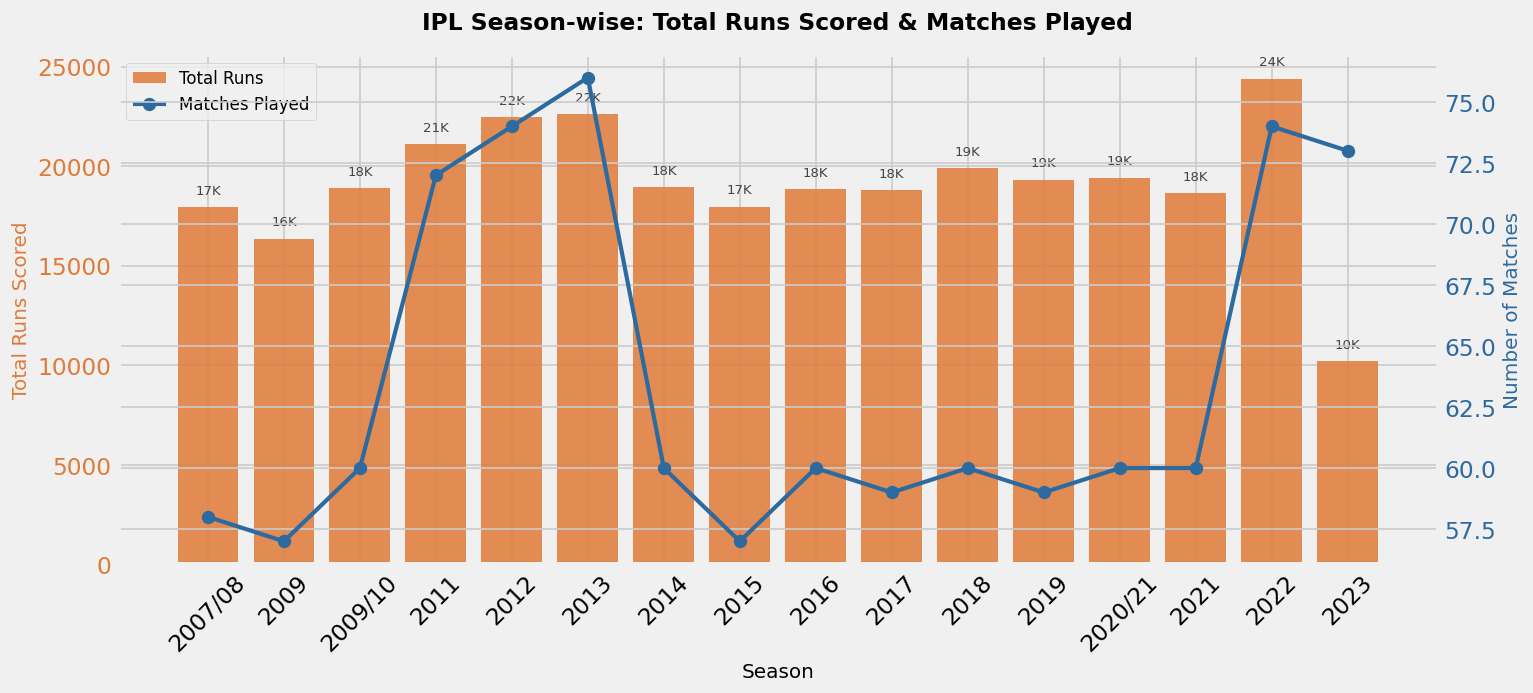


Top 3 highest-scoring seasons:
season  total_runs_season  match_count
  2022            24395.0           74
  2013            22602.0           76
  2012            22453.0           74


In [7]:
# ── Merge deliveries with matches to get the 'season' column ───────────────────
# deliveries has 'match_id'; matches has 'id' (same match identifier)
del_with_season = deliveries.merge(
    matches_clean[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# ── Aggregate: total runs per season ──────────────────────────────────────────
season_runs = (
    del_with_season
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
    .rename(columns={'total_runs': 'total_runs_season'})
)

# ── Aggregate: match count per season ────────────────────────────────────────
season_matches = (
    matches_clean
    .groupby('season')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'match_count'})
)

# ── Combine both ─────────────────────────────────────────────────────────────
season_summary = season_runs.merge(season_matches, on='season')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))

# Bar chart: total runs (left y-axis)
bars = ax1.bar(
    season_summary['season'],
    season_summary['total_runs_season'],
    color='#E07B39',
    alpha=0.85,
    zorder=2,
    label='Total Runs'
)
ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Total Runs Scored', color='#E07B39', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#E07B39')
ax1.set_xticks(season_summary['season'])
ax1.set_xticklabels(season_summary['season'], rotation=45)

# Annotate bars with run totals
for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 500,
        f'{int(h/1000)}K',
        ha='center', va='bottom', fontsize=8, color='#444'
    )

# Line chart: match count (right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    season_summary['season'],
    season_summary['match_count'],
    color='#2D6A9F',
    marker='o',
    linewidth=2.5,
    markersize=7,
    label='Matches Played'
)
ax2.set_ylabel('Number of Matches', color='#2D6A9F', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2D6A9F')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('IPL Season-wise: Total Runs Scored & Matches Played', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('analysis1_season_runs.png', bbox_inches='tight')
plt.show()
print("\nTop 3 highest-scoring seasons:")
print(season_summary.nlargest(3, 'total_runs_season')[['season','total_runs_season','match_count']].to_string(index=False))

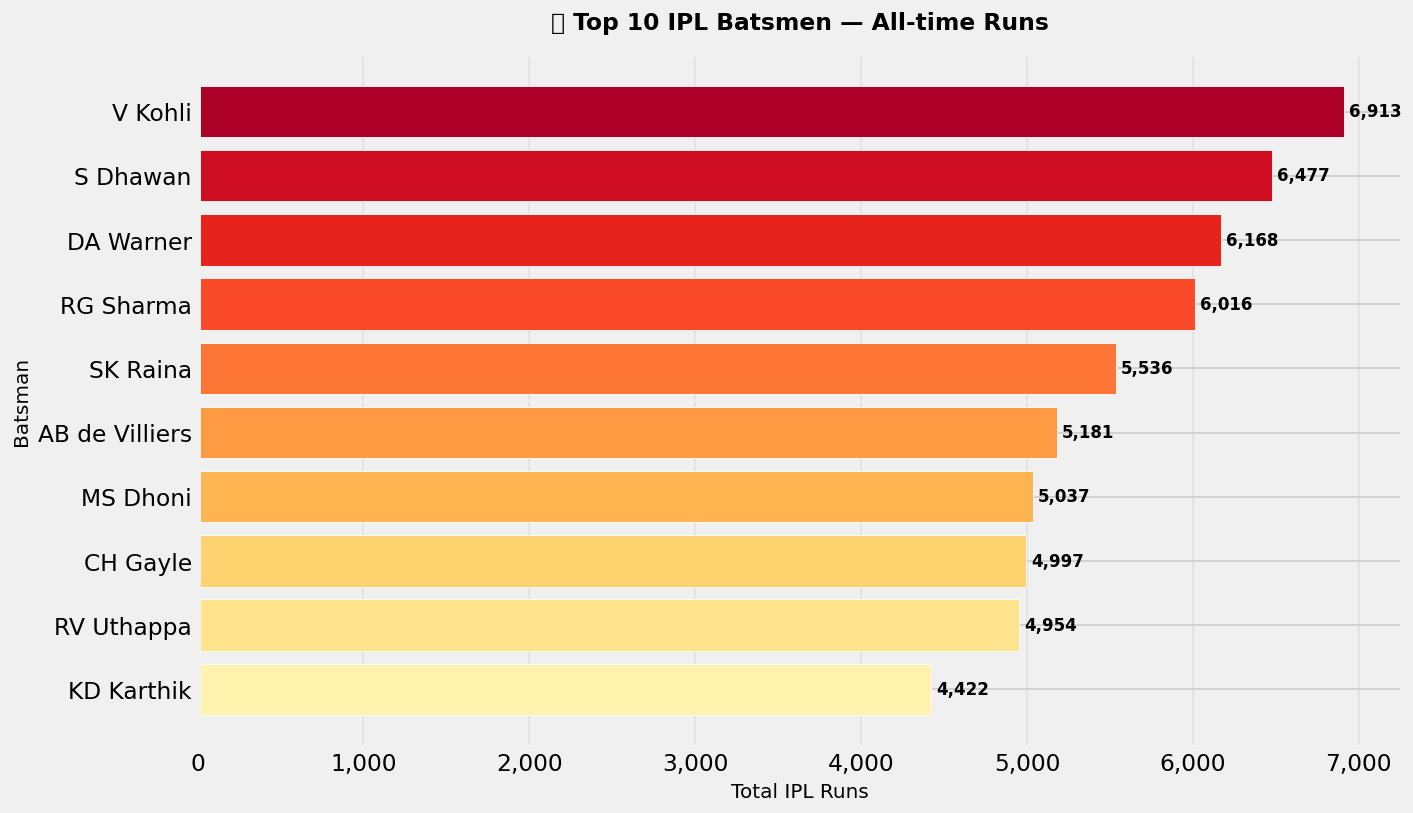

        batter  total_runs
       V Kohli      6913.0
      S Dhawan      6477.0
     DA Warner      6168.0
     RG Sharma      6016.0
      SK Raina      5536.0
AB de Villiers      5181.0
      MS Dhoni      5037.0
      CH Gayle      4997.0
    RV Uthappa      4954.0
    KD Karthik      4422.0


In [9]:
# ── Aggregate runs per batsman ─────────────────────────────────────────────────
# 'batsman_runs' = runs credited to the batsman (excludes extras like wides)
batsman_runs = (
    deliveries
    .groupby('batter')['batsman_runs']
    .sum()
    .reset_index()
    .rename(columns={'batsman_runs': 'total_runs'})
    .sort_values('total_runs', ascending=False)
    .head(10)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Use a custom gradient-like palette (dark orange to light)
palette = sns.color_palette('YlOrRd_r', n_colors=10)

bars = ax.barh(
    batsman_runs['batter'],
    batsman_runs['total_runs'],
    color=palette,
    edgecolor='white',
    linewidth=0.5
)

# Invert y-axis so highest scorer is at the top
ax.invert_yaxis()

# Annotate each bar with the run total
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 30, bar.get_y() + bar.get_height() / 2,
        f'{int(w):,}',
        va='center', ha='left', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Total IPL Runs', fontsize=12)
ax.set_ylabel('Batsman', fontsize=12)
ax.set_title('🏆 Top 10 IPL Batsmen — All-time Runs', fontsize=14, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('analysis2_top_batsmen.png', bbox_inches='tight')
plt.show()
print(batsman_runs.to_string(index=False))

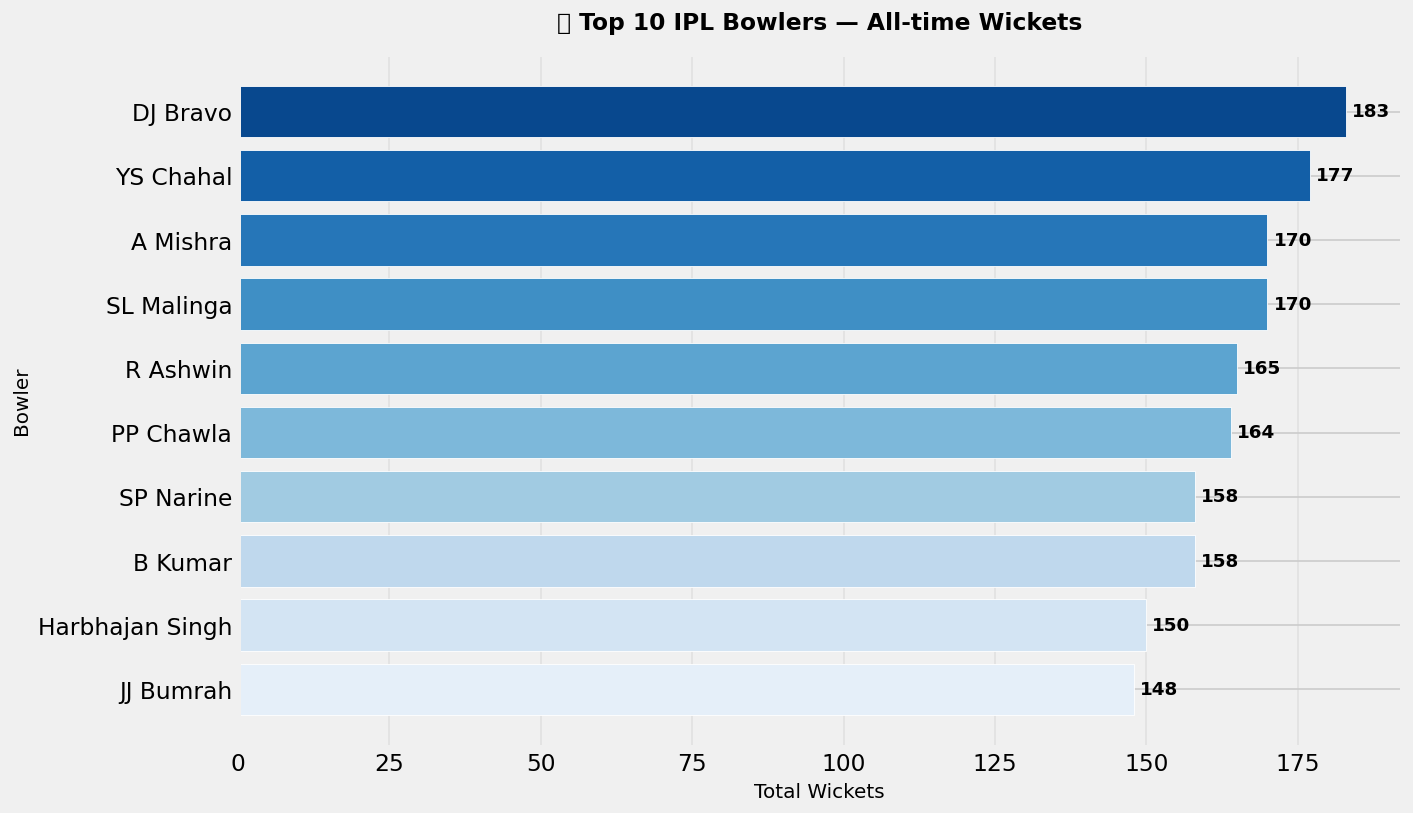

         bowler  total_wickets
       DJ Bravo            183
      YS Chahal            177
       A Mishra            170
     SL Malinga            170
       R Ashwin            165
      PP Chawla            164
      SP Narine            158
        B Kumar            158
Harbhajan Singh            150
      JJ Bumrah            148


In [10]:
# ── Filter: only bowler-credited dismissals (no run-outs) ─────────────────────
# Dismissal types where the BOWLER gets credit:
bowler_wicket_types = [
    'caught', 'bowled', 'lbw', 'stumped',
    'caught and bowled', 'hit wicket'
]

wickets_df = deliveries[
    deliveries['dismissal_kind'].isin(bowler_wicket_types)
].copy()

# ── Count wickets per bowler ──────────────────────────────────────────────────
bowler_wickets = (
    wickets_df
    .groupby('bowler')['player_dismissed']
    .count()
    .reset_index()
    .rename(columns={'player_dismissed': 'total_wickets'})
    .sort_values('total_wickets', ascending=False)
    .head(10)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

palette = sns.color_palette('Blues_r', n_colors=10)

bars = ax.barh(
    bowler_wickets['bowler'],
    bowler_wickets['total_wickets'],
    color=palette,
    edgecolor='white',
    linewidth=0.5
)

ax.invert_yaxis()  # highest wicket-taker at the top

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 1, bar.get_y() + bar.get_height() / 2,
        f'{int(w)}',
        va='center', ha='left', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_ylabel('Bowler', fontsize=12)
ax.set_title('🎳 Top 10 IPL Bowlers — All-time Wickets', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('analysis3_top_bowlers.png', bbox_inches='tight')
plt.show()
print(bowler_wickets.to_string(index=False))

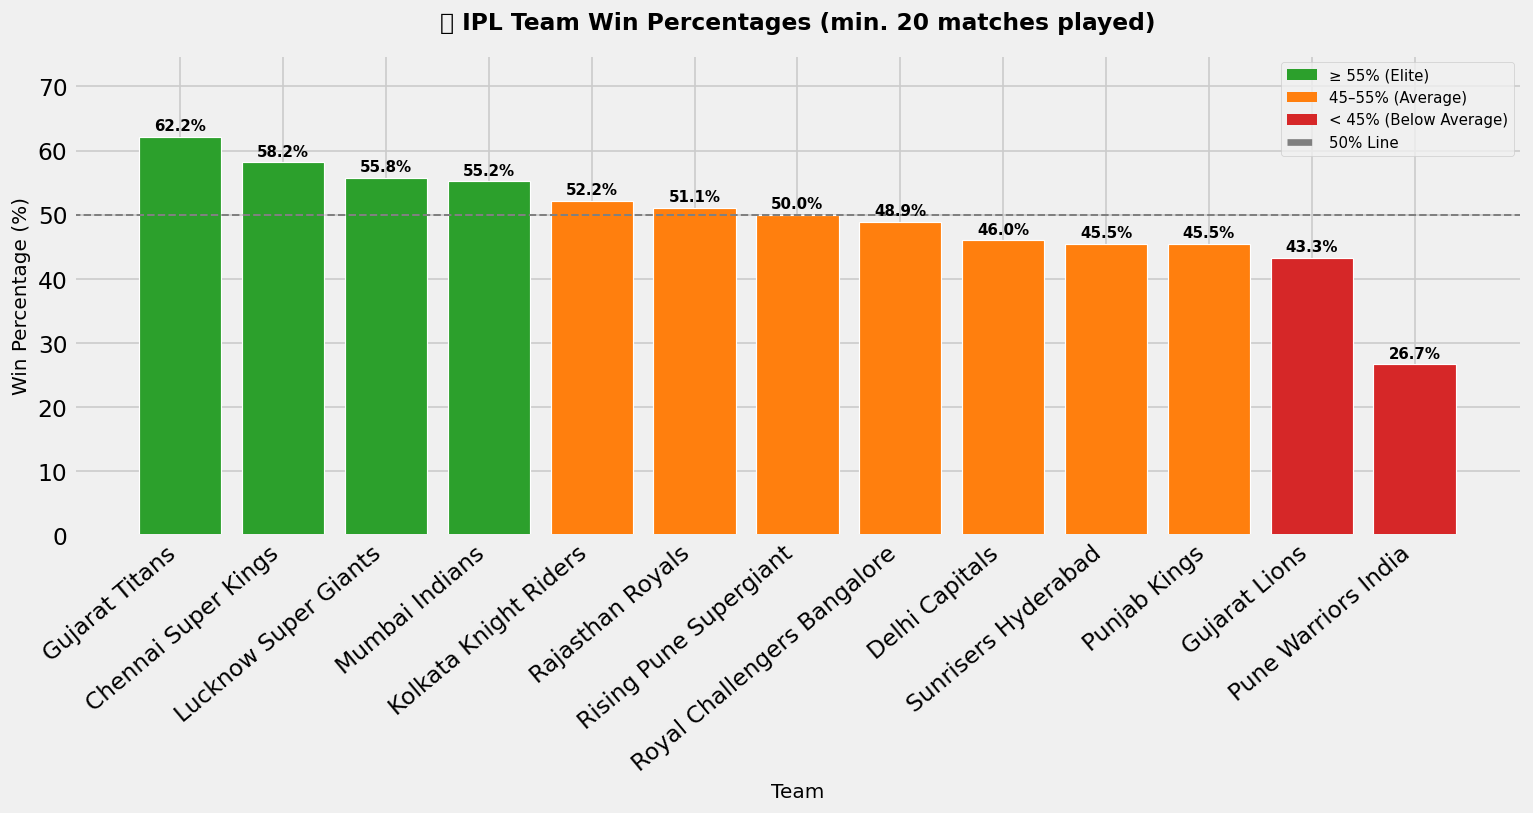

                       team  matches  wins  win_pct
             Gujarat Titans       45    28     62.2
        Chennai Super Kings      237   138     58.2
       Lucknow Super Giants       43    24     55.8
             Mumbai Indians      261   144     55.2
      Kolkata Knight Riders      251   131     52.2
           Rajasthan Royals      219   112     51.1
     Rising Pune Supergiant       30    15     50.0
Royal Challengers Bangalore      237   116     48.9
             Delhi Capitals      250   115     46.0
        Sunrisers Hyderabad      257   117     45.5
               Punjab Kings      246   112     45.5
              Gujarat Lions       30    13     43.3
        Pune Warriors India       45    12     26.7


In [11]:
# ── Count total matches each team played (they appear in team1 OR team2) ───────
team1_counts = matches_clean['team1'].value_counts()
team2_counts = matches_clean['team2'].value_counts()

# Add both counts together — each team appears in team1 for some games, team2 for others
total_played = (team1_counts.add(team2_counts, fill_value=0)).astype(int)

# ── Count wins per team ───────────────────────────────────────────────────────
wins = matches_clean['winner'].value_counts()

# ── Build win-percentage DataFrame ───────────────────────────────────────────
win_df = pd.DataFrame({
    'team'        : total_played.index,
    'matches'     : total_played.values,
    'wins'        : wins.reindex(total_played.index, fill_value=0).values
})
win_df['win_pct'] = (win_df['wins'] / win_df['matches'] * 100).round(1)

# Keep only teams with at least 20 matches (avoids tiny-sample distortion)
win_df = win_df[win_df['matches'] >= 20].sort_values('win_pct', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

# Color-code: green for ≥ 55%, orange for 45-55%, red for < 45%
colors = [
    '#2ca02c' if p >= 55 else ('#ff7f0e' if p >= 45 else '#d62728')
    for p in win_df['win_pct']
]

bars = ax.bar(
    win_df['team'],
    win_df['win_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

# Reference line at 50% (breakeven)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50% Win Rate')

# Annotate bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.5,
        f'{h}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win Percentage (%)', fontsize=12)
ax.set_title('🏆 IPL Team Win Percentages (min. 20 matches played)', fontsize=14, pad=15)
ax.set_ylim(0, 75)
plt.xticks(rotation=40, ha='right')

# Custom legend for color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='≥ 55% (Elite)'),
    Patch(facecolor='#ff7f0e', label='45–55% (Average)'),
    Patch(facecolor='#d62728', label='< 45% (Below Average)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='50% Line')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('analysis4_win_pct.png', bbox_inches='tight')
plt.show()
print(win_df[['team','matches','wins','win_pct']].to_string(index=False))

Toss winner also won the match: 50.8% of the time

── Win rate by toss decision ──
decision  wins_after_toss  total  win_pct
     bat              177    390     45.4
   field              377    700     53.9


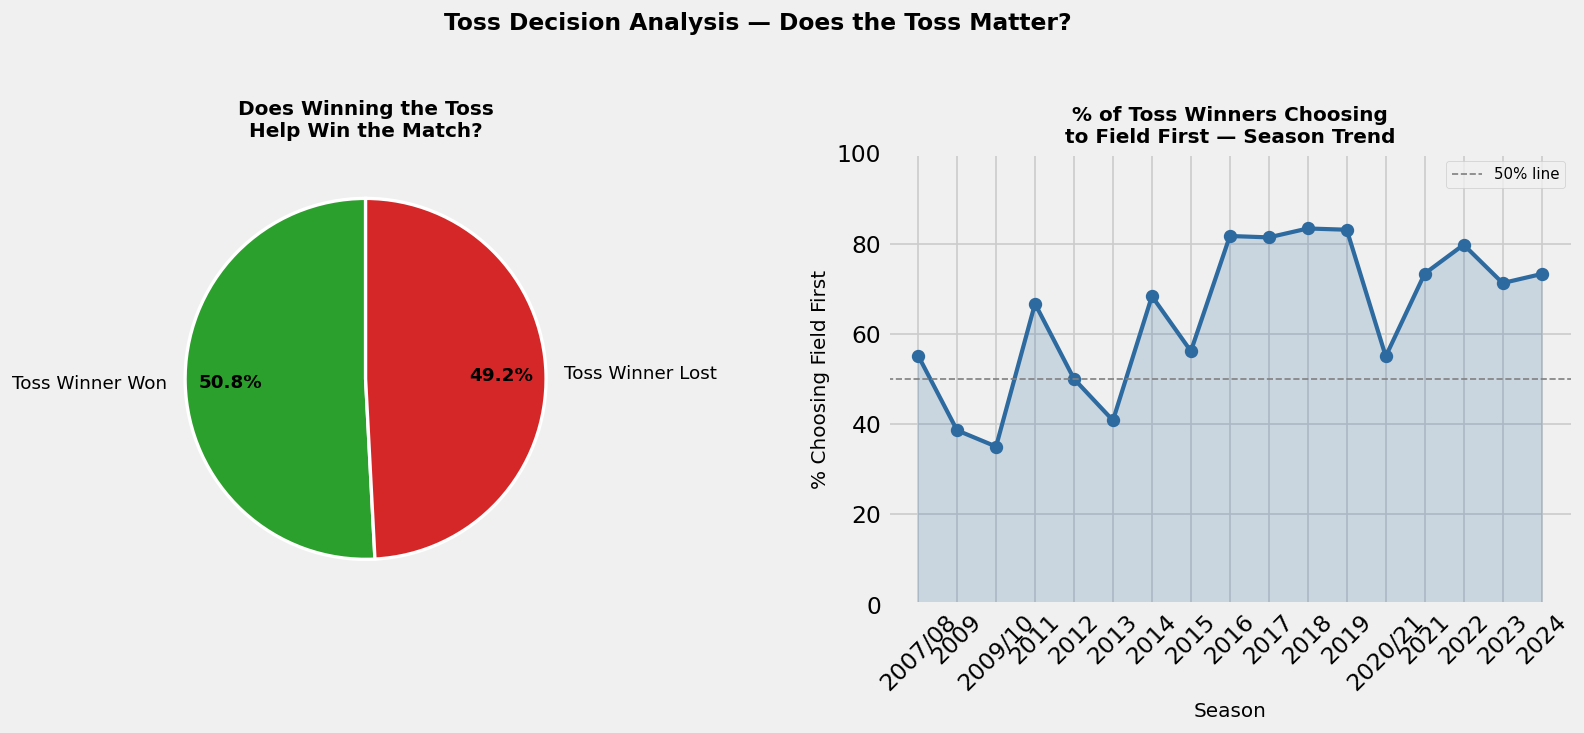

In [13]:
# ── Did the toss winner win the match? ────────────────────────────────────────
matches_clean['toss_winner_won'] = (
    matches_clean['toss_winner'] == matches_clean['winner']
)

toss_win_rate = matches_clean['toss_winner_won'].mean() * 100
print(f"Toss winner also won the match: {toss_win_rate:.1f}% of the time")

# ── By toss decision: bat vs field ────────────────────────────────────────────
toss_decision = (
    matches_clean
    .groupby('toss_decision')['toss_winner_won']
    .agg(['sum', 'count'])
    .reset_index()
)
toss_decision.columns = ['decision', 'wins_after_toss', 'total']
toss_decision['win_pct'] = (toss_decision['wins_after_toss'] / toss_decision['total'] * 100).round(1)

print("\n── Win rate by toss decision ──")
print(toss_decision.to_string(index=False))

# ── Season-wise trend of 'field first' preference ─────────────────────────────
field_trend = (
    matches_clean
    .groupby('season')['toss_decision']
    .apply(lambda x: (x == 'field').sum() / len(x) * 100)
    .reset_index()
    .rename(columns={'toss_decision': 'field_pct'})
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Pie chart — toss winner wins vs loses
ax = axes[0]
labels = ['Toss Winner Won', 'Toss Winner Lost']
sizes  = [toss_win_rate, 100 - toss_win_rate]
colors = ['#2ca02c', '#d62728']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Does Winning the Toss\nHelp Win the Match?', fontsize=12, pad=10)

# Right: Line chart — % choosing 'field first' over seasons
ax2 = axes[1]
ax2.fill_between(
    field_trend['season'],
    field_trend['field_pct'],
    alpha=0.2, color='#2D6A9F'
)
ax2.plot(
    field_trend['season'],
    field_trend['field_pct'],
    color='#2D6A9F', marker='o', linewidth=2.5, markersize=7
)
ax2.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% line')
ax2.set_title('% of Toss Winners Choosing\nto Field First — Season Trend', fontsize=12)
ax2.set_xlabel('Season')
ax2.set_ylabel('% Choosing Field First')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.set_xticks(field_trend['season'])
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Toss Decision Analysis — Does the Toss Matter?', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis5_toss.png', bbox_inches='tight')
plt.show()

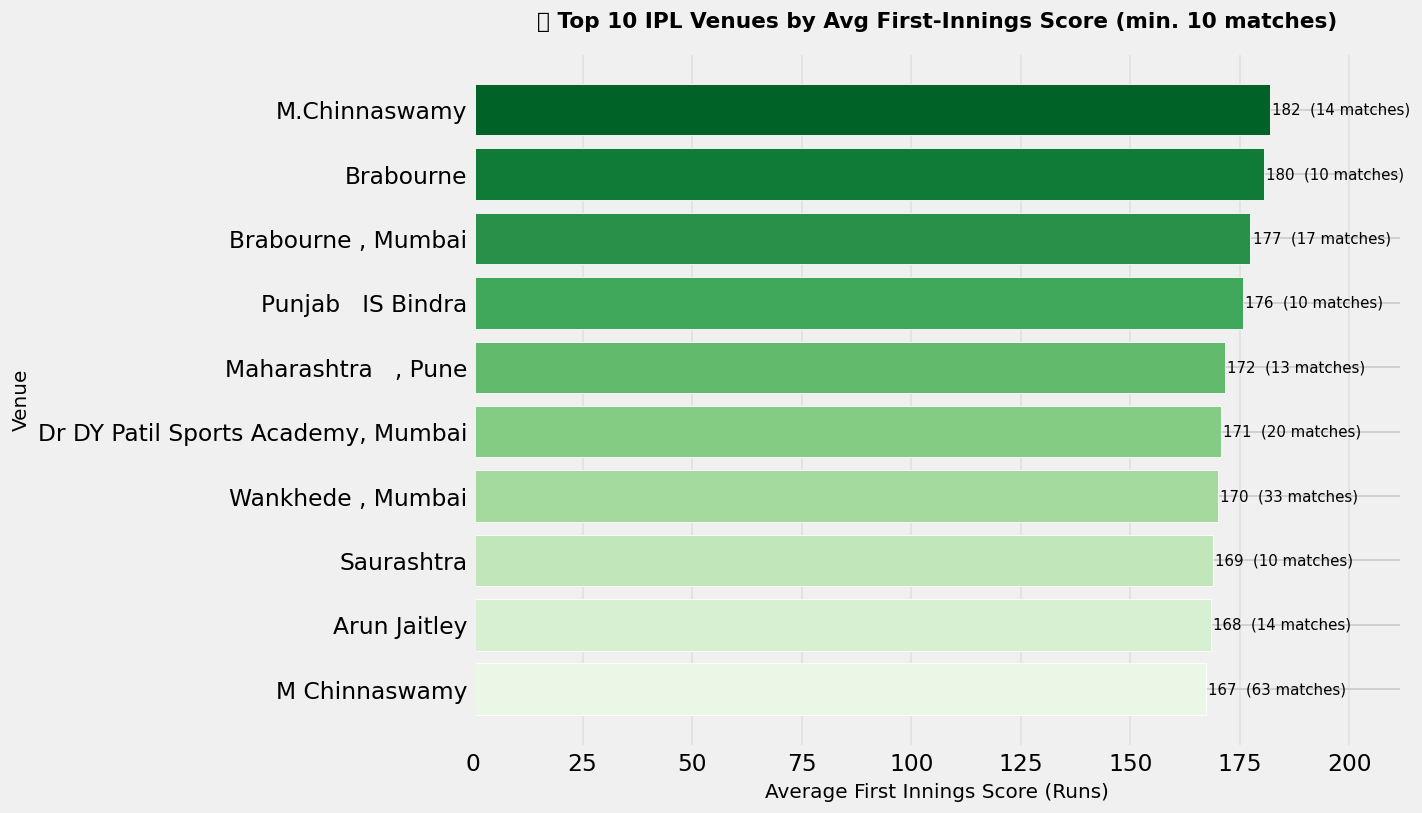

                                        venue  avg_score  matches
                        M.Chinnaswamy Stadium      181.9       14
                            Brabourne Stadium      180.4       10
                    Brabourne Stadium, Mumbai      177.4       17
 Punjab Cricket Association IS Bindra Stadium      175.6       10
Maharashtra Cricket Association Stadium, Pune      171.5       13
           Dr DY Patil Sports Academy, Mumbai      170.7       20
                     Wankhede Stadium, Mumbai      170.0       33
       Saurashtra Cricket Association Stadium      168.9       10
                         Arun Jaitley Stadium      168.3       14
                        M Chinnaswamy Stadium      167.3       63


In [14]:
# ── Filter to first innings only ──────────────────────────────────────────────
first_innings = deliveries[deliveries['inning'] == 1].copy()

# ── Total runs per match in first innings ─────────────────────────────────────
match_scores = (
    first_innings
    .groupby('match_id')['total_runs']
    .sum()
    .reset_index()
    .rename(columns={'total_runs': 'first_innings_score'})
)

# ── Merge with matches to get venue information ───────────────────────────────
match_scores = match_scores.merge(
    matches_clean[['id', 'venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# ── Average first-innings score per venue ─────────────────────────────────────
venue_scores = (
    match_scores
    .groupby('venue')['first_innings_score']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_score', 'count': 'matches'})
)

# Keep venues with at least 10 matches (sufficient sample)
venue_scores = (
    venue_scores[venue_scores['matches'] >= 10]
    .sort_values('avg_score', ascending=False)
    .head(10)
)
venue_scores['avg_score'] = venue_scores['avg_score'].round(1)

# Shorten long venue names for the chart
venue_scores['venue_short'] = venue_scores['venue'].str.replace(
    r'(Stadium|Ground|Cricket|International|Association)', '', regex=True
).str.strip()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

palette = sns.color_palette('Greens_r', n_colors=10)

bars = ax.barh(
    venue_scores['venue_short'],
    venue_scores['avg_score'],
    color=palette,
    edgecolor='white',
    linewidth=0.5
)
ax.invert_yaxis()

for bar, (_, row) in zip(bars, venue_scores.iterrows()):
    w = bar.get_width()
    ax.text(
        w + 0.5, bar.get_y() + bar.get_height() / 2,
        f'{w:.0f}  ({row["matches"]} matches)',
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Average First Innings Score (Runs)', fontsize=12)
ax.set_ylabel('Venue', fontsize=12)
ax.set_title('🏟️ Top 10 IPL Venues by Avg First-Innings Score (min. 10 matches)', fontsize=13, pad=15)
ax.set_xlim(0, venue_scores['avg_score'].max() + 30)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('analysis6_venues.png', bbox_inches='tight')
plt.show()
print(venue_scores[['venue','avg_score','matches']].to_string(index=False))

        player  awards
AB de Villiers      25
      CH Gayle      22
     RG Sharma      19
       V Kohli      18
     DA Warner      18
      MS Dhoni      17
     YK Pathan      16
     RA Jadeja      16
     SR Watson      16
    AD Russell      15


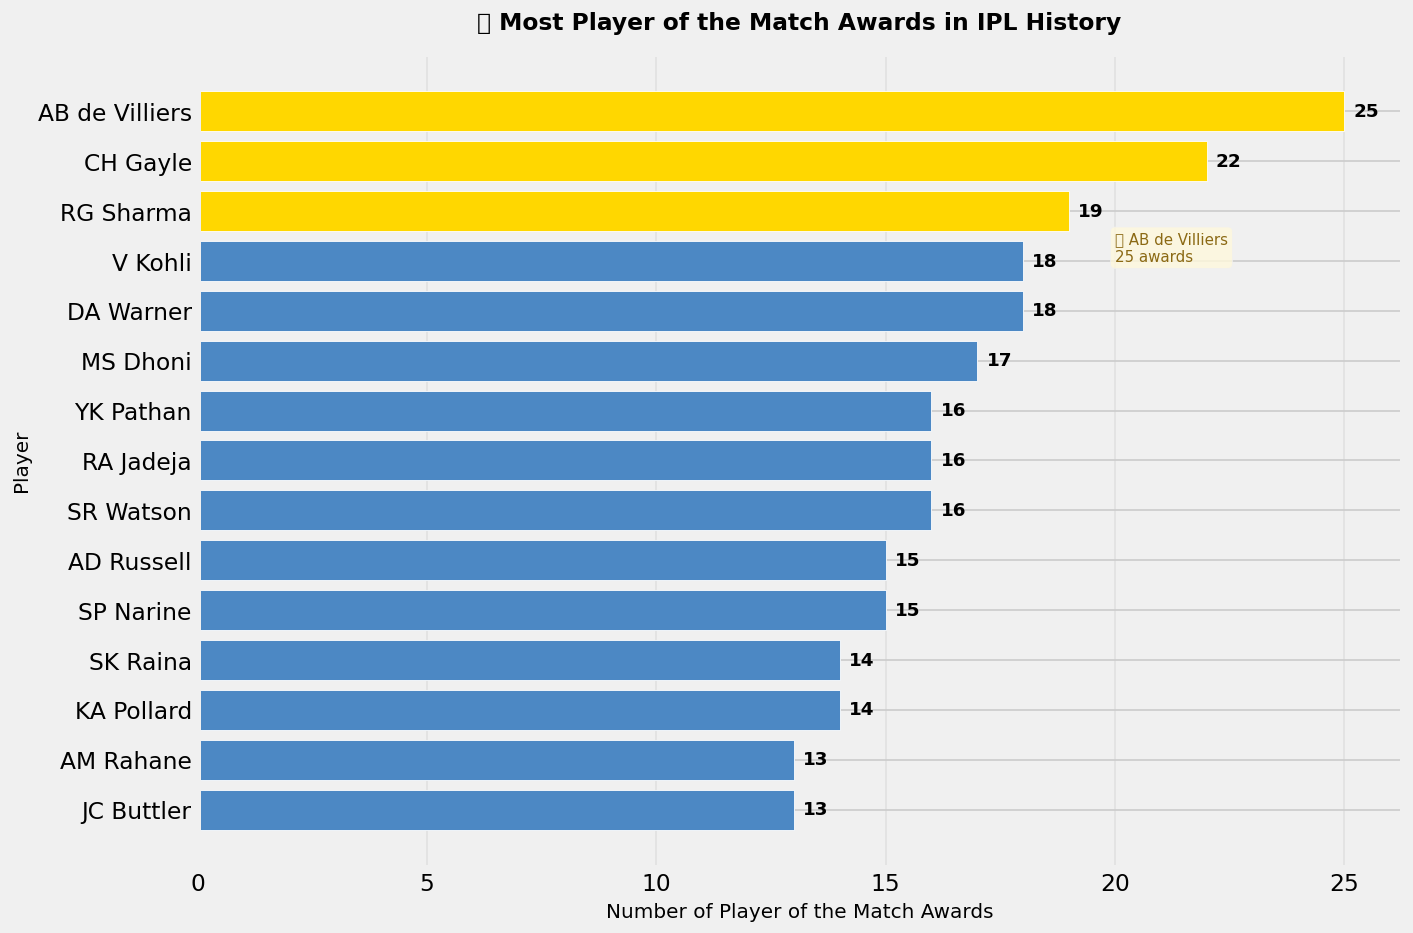

In [15]:
# ── Count Player of the Match awards ─────────────────────────────────────────
potm = (
    matches_clean['player_of_match']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'player', 'player_of_match': 'awards'})
    .head(15)
)
# Handle newer pandas versions where column name differs
if 'player_of_match' not in potm.columns:
    potm.columns = ['player', 'awards']
else:
    potm = potm.rename(columns={'player_of_match': 'player', 'count': 'awards'})
    if 'player' not in potm.columns:
        potm.columns = ['player', 'awards']

print(potm.head(10).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Color: gold for top 3, silver-blue for rest
bar_colors = ['#FFD700', '#FFD700', '#FFD700'] + ['#4C88C4'] * (len(potm) - 3)

bars = ax.barh(
    potm['player'],
    potm['awards'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.2, bar.get_y() + bar.get_height() / 2,
        str(int(w)),
        va='center', ha='left', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Number of Player of the Match Awards', fontsize=12)
ax.set_ylabel('Player', fontsize=12)
ax.set_title('⭐ Most Player of the Match Awards in IPL History', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

# Gold star annotation for top player
top_player = potm.iloc[0]
ax.annotate(
    f'🥇 {top_player["player"]}\n{top_player["awards"]} awards',
    xy=(top_player['awards'], 0),
    xytext=(top_player['awards'] - 5, 3),
    fontsize=9, color='#8B6914',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF8DC', alpha=0.8)
)

plt.tight_layout()
plt.savefig('analysis7_potm.png', bbox_inches='tight')
plt.show()

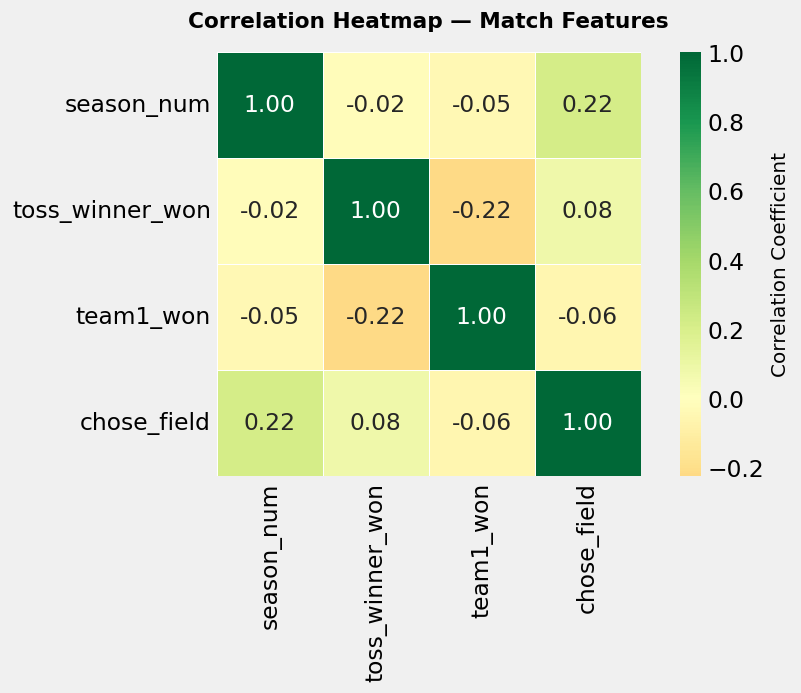

Values close to 0 → no strong linear relationship between those features.


In [17]:
# ── Encode categorical columns as numbers for correlation ─────────────────────
heatmap_df = matches_clean.copy()

# Binary: did toss winner win match?
heatmap_df['toss_winner_won']   = (heatmap_df['toss_winner'] == heatmap_df['winner']).astype(int)
# Binary: did team1 win?
heatmap_df['team1_won']         = (heatmap_df['team1'] == heatmap_df['winner']).astype(int)
# Binary: chose to field first?
heatmap_df['chose_field']       = (heatmap_df['toss_decision'] == 'field').astype(int)
# Convert season to numeric (extract first 4 digits for year)
heatmap_df['season_num']        = heatmap_df['season'].str[:4].astype(int)

corr_cols = ['season_num', 'toss_winner_won', 'team1_won', 'chose_field']
corr_matrix = heatmap_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'label': 'Correlation Coefficient'}
)
ax.set_title('Correlation Heatmap — Match Features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('analysis_bonus_heatmap.png', bbox_inches='tight')
plt.show()
print("Values close to 0 → no strong linear relationship between those features.")